# causal-learn Tutorial 02: Synthetic Data For Causal Discovery

This notebook builds the reusable synthetic datasets used by later `causal-learn` tutorials. Causal discovery is easiest to learn when we know the true graph. With a known graph, we can separate three questions that are often mixed together in real data:

- Did the algorithm recover the right adjacencies?
- Did it orient the recoverable arrows correctly?
- Did the data-generating assumptions match the algorithm's assumptions?

The goal here is not to create a giant simulation benchmark. The goal is to create a small, inspectable dataset library that teaches the main discovery regimes: linear Gaussian data, non-Gaussian noise, nonlinear mechanisms, discrete variables, hidden confounding, and nonstationary environments.

Each dataset will be saved with:

- the observed data table;
- a variable dictionary;
- the true graph edge table;
- simple diagnostics that confirm the generated data look like the intended scenario.

Later notebooks can load these files instead of redefining structural equations from scratch.

## Notebook Flow

We will build the data factory in a deliberate order:

1. Set up imports, output folders, random seeds, and display options.
2. Define the base teaching DAG shared across most datasets.
3. Render the true DAG in the same style as the other tutorial figures.
4. Define structural-equation generators for several data regimes.
5. Save datasets, edge tables, metadata, and diagnostics.
6. Inspect summaries that make the scenario differences visible.
7. Close with a manifest showing exactly what downstream notebooks can load.

This notebook does not run a discovery algorithm yet. It prepares the ground truth that discovery notebooks will try to recover.

## Setup

The setup cell imports the scientific Python stack, prepares output folders, fixes the random seed, and records package versions. The dedicated `outputs/datasets` folder keeps generated CSV files separate from figures and tables. All paths are relative to this tutorial folder so the notebooks remain portable inside the repository.

In [1]:
from pathlib import Path
from importlib.metadata import PackageNotFoundError, version
import os
import warnings

# Keep local caches inside the repository workspace during notebook execution.
os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".matplotlib_cache"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from causallearn.graph.GraphNode import GraphNode
from causallearn.graph.Dag import Dag
from causallearn.graph.Edge import Edge
from causallearn.graph.Endpoint import Endpoint

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 140)

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != "causal_learn":
    NOTEBOOK_DIR = Path("notebooks/tutorials/causal_learn").resolve()
else:
    NOTEBOOK_DIR = NOTEBOOK_DIR.resolve()

OUTPUT_DIR = NOTEBOOK_DIR / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
DATASET_DIR = OUTPUT_DIR / "datasets"
REPORT_DIR = OUTPUT_DIR / "reports"
for directory in [OUTPUT_DIR, FIGURE_DIR, TABLE_DIR, DATASET_DIR, REPORT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

NOTEBOOK_PREFIX = "02"
RANDOM_SEED = 42
N_ROWS = 2_500
rng = np.random.default_rng(RANDOM_SEED)


def pkg_version(package_name: str) -> str:
    """Return a package version string without failing if metadata is unavailable."""
    try:
        return version(package_name)
    except PackageNotFoundError:
        return "not installed"

version_table = pd.DataFrame(
    [
        {"package": "causal-learn", "version": pkg_version("causal-learn")},
        {"package": "numpy", "version": pkg_version("numpy")},
        {"package": "pandas", "version": pkg_version("pandas")},
        {"package": "matplotlib", "version": pkg_version("matplotlib")},
        {"package": "seaborn", "version": pkg_version("seaborn")},
    ]
)
version_table

,package,version
0,causal-learn,0.1.4.5
1,numpy,2.4.4
2,pandas,3.0.2
3,matplotlib,3.10.9
4,seaborn,0.13.2


The version table and random seed make this notebook repeatable. If a later graph-recovery result changes, we can check whether the data changed, the package version changed, or the discovery settings changed.

## Dataset Design Principles

Synthetic discovery data should be simple enough to audit but varied enough to stress different assumptions. This registry describes the scenarios we will generate. Each scenario has a clear purpose: some are friendly to PC-style methods, some are better suited to functional methods, and some intentionally violate assumptions so later notebooks can show failure modes.

In [2]:
dataset_registry = pd.DataFrame(
    [
        {
            "dataset_name": "linear_gaussian",
            "row_count": N_ROWS,
            "variable_type": "continuous",
            "main_stress_test": "Linear additive mechanisms with Gaussian noise.",
            "use_later_for": "PC, Fisher-Z tests, GES, baseline graph recovery.",
            "known_limitation": "Purely observational data may not orient every Markov-equivalent edge.",
        },
        {
            "dataset_name": "linear_nongaussian",
            "row_count": N_ROWS,
            "variable_type": "continuous",
            "main_stress_test": "Linear mechanisms with non-Gaussian noise.",
            "use_later_for": "LiNGAM-style direction learning and non-Gaussian diagnostics.",
            "known_limitation": "Non-Gaussianity helps only when the linear model is a reasonable approximation.",
        },
        {
            "dataset_name": "nonlinear_continuous",
            "row_count": N_ROWS,
            "variable_type": "continuous",
            "main_stress_test": "Nonlinear parent effects and interactions.",
            "use_later_for": "Kernel tests, nonlinear functional methods, robustness checks.",
            "known_limitation": "Linear tests may miss or distort nonlinear dependence.",
        },
        {
            "dataset_name": "discrete_mixed",
            "row_count": N_ROWS,
            "variable_type": "binary and ordinal",
            "main_stress_test": "Discrete outcomes generated from latent logits.",
            "use_later_for": "Discrete conditional-independence tests and mixed-data cautions.",
            "known_limitation": "Treating these variables as Gaussian continuous data is a modeling mismatch.",
        },
        {
            "dataset_name": "hidden_confounder_observed",
            "row_count": N_ROWS,
            "variable_type": "continuous with one omitted cause",
            "main_stress_test": "A latent variable affects multiple observed variables.",
            "use_later_for": "FCI/PAG examples and hidden-confounding sensitivity.",
            "known_limitation": "The observed variables alone do not satisfy causal sufficiency.",
        },
        {
            "dataset_name": "nonstationary_continuous",
            "row_count": N_ROWS,
            "variable_type": "continuous plus environment label",
            "main_stress_test": "Mechanisms and distributions shift across environments.",
            "use_later_for": "CD-NOD and stability diagnostics across environments.",
            "known_limitation": "Pooling environments can hide mechanism changes.",
        },
    ]
)

dataset_registry.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_dataset_registry.csv", index=False)
dataset_registry

,dataset_name,row_count,variable_type,main_stress_test,use_later_for,known_limitation
0,linear_gaussian,2500,continuous,Linear additive mechanisms with Gaussian noise.,"PC, Fisher-Z tests, GES, baseline graph recovery.",Purely observational data may not orient every Markov-equivalent edge.
1,linear_nongaussian,2500,continuous,Linear mechanisms with non-Gaussian noise.,LiNGAM-style direction learning and non-Gaussian diagnostics.,Non-Gaussianity helps only when the linear model is a reasonable approximation.
2,nonlinear_continuous,2500,continuous,Nonlinear parent effects and interactions.,"Kernel tests, nonlinear functional methods, robustness checks.",Linear tests may miss or distort nonlinear dependence.
3,discrete_mixed,2500,binary and ordinal,Discrete outcomes generated from latent logits.,Discrete conditional-independence tests and mixed-data cautions.,Treating these variables as Gaussian continuous data is a modeling mismatch.
4,hidden_confounder_observed,2500,continuous with one omitted cause,A latent variable affects multiple observed variables.,FCI/PAG examples and hidden-confounding sensitivity.,The observed variables alone do not satisfy causal sufficiency.
5,nonstationary_continuous,2500,continuous plus environment label,Mechanisms and distributions shift across environments.,CD-NOD and stability diagnostics across environments.,Pooling environments can hide mechanism changes.


The registry is the notebook's contract with later tutorials. Each generated file should be used for the algorithm family it was designed to teach, not as a universal benchmark. This prevents an easy mistake: judging an algorithm harshly on a dataset that violates its core assumptions without saying so.

## Base Teaching DAG

Most datasets share the same observed causal graph. The variable names match the introductory causal-learn notebook so the tutorial series feels continuous:

- `need` and `intent` are exogenous drivers.
- `match` depends on `need` and `intent`.
- `engagement` depends on `match`.
- `renewal` depends on `intent` and `engagement`.
- `support` depends on `engagement`.

This graph is a teaching DAG, not a claim about any real product system. Its purpose is to create known parent-child relationships that are easy to inspect.

In [3]:
base_nodes = ["need", "intent", "match", "engagement", "renewal", "support"]
base_edge_table = pd.DataFrame(
    [
        {"source": "need", "target": "match", "edge_type": "directed", "mechanism": "Need changes what a good match means."},
        {"source": "intent", "target": "match", "edge_type": "directed", "mechanism": "Current intent changes recommendation relevance."},
        {"source": "match", "target": "engagement", "edge_type": "directed", "mechanism": "Better matching increases engagement depth."},
        {"source": "intent", "target": "renewal", "edge_type": "directed", "mechanism": "Intent directly affects later value."},
        {"source": "engagement", "target": "renewal", "edge_type": "directed", "mechanism": "Engagement contributes to renewal value."},
        {"source": "engagement", "target": "support", "edge_type": "directed", "mechanism": "Engagement creates more chances for support contact."},
    ]
)

base_edge_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_base_true_dag_edges.csv", index=False)
base_edge_table

,source,target,edge_type,mechanism
0,need,match,directed,Need changes what a good match means.
1,intent,match,directed,Current intent changes recommendation relevance.
2,match,engagement,directed,Better matching increases engagement depth.
3,intent,renewal,directed,Intent directly affects later value.
4,engagement,renewal,directed,Engagement contributes to renewal value.
5,engagement,support,directed,Engagement creates more chances for support contact.


The edge table is the ground truth for the base scenarios. Later notebooks can compare a learned graph against this table to compute adjacency and arrow metrics. Keeping the graph in table form also makes it easy to save, reload, and inspect without relying only on a picture.

## Render The Base DAG

The figure uses the same visual style as the other tutorial DAGs: a wide canvas, rounded pastel boxes, bold labels, and dark annotation arrows with clear arrowhead spacing. Visual consistency matters because these notebooks are meant to be read as a tutorial sequence.

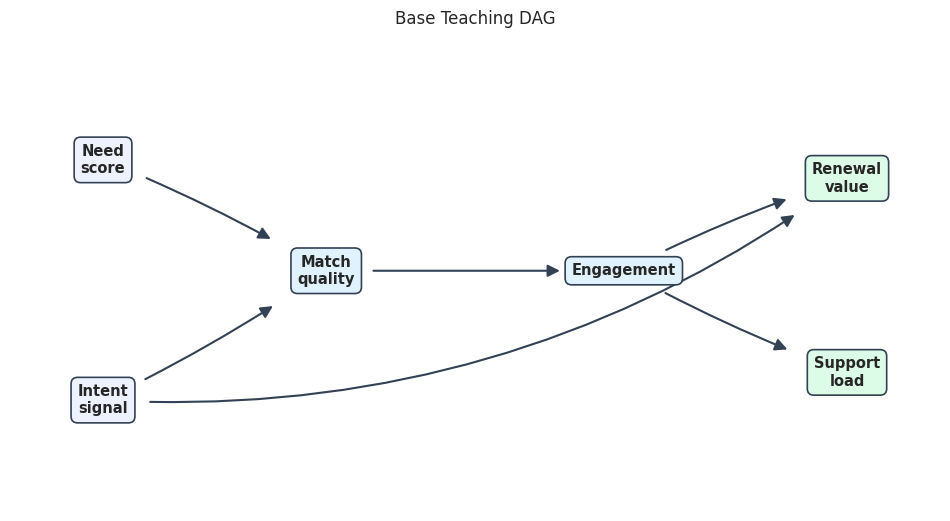

PosixPath('/home/apex/Documents/ranking_sys/notebooks/tutorials/causal_learn/outputs/figures/02_base_teaching_dag.png')

In [4]:
base_labels = {
    "need": "Need\nscore",
    "intent": "Intent\nsignal",
    "match": "Match\nquality",
    "engagement": "Engagement",
    "renewal": "Renewal\nvalue",
    "support": "Support\nload",
}

base_positions = {
    "need": (0.10, 0.76),
    "intent": (0.10, 0.24),
    "match": (0.34, 0.52),
    "engagement": (0.66, 0.52),
    "renewal": (0.90, 0.72),
    "support": (0.90, 0.30),
}

base_node_colors = {
    "need": "#eef2ff",
    "intent": "#eef2ff",
    "match": "#e0f2fe",
    "engagement": "#e0f2fe",
    "renewal": "#dcfce7",
    "support": "#dcfce7",
}

base_edge_radii = {
    ("need", "match"): -0.04,
    ("intent", "match"): 0.04,
    ("match", "engagement"): 0.00,
    ("intent", "renewal"): 0.18,
    ("engagement", "renewal"): -0.04,
    ("engagement", "support"): 0.04,
}


def draw_teaching_style_dag(edge_table, labels, positions, node_colors, title, path, edge_radii=None):
    """Draw a small DAG using the shared tutorial visual style."""
    edge_radii = edge_radii or {}
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_axis_off()

    for row in edge_table.itertuples(index=False):
        source = row.source
        target = row.target
        edge_type = getattr(row, "edge_type", "directed")
        ax.annotate(
            "",
            xy=positions[target],
            xytext=positions[source],
            arrowprops=dict(
                arrowstyle="-|>",
                color="#334155",
                linewidth=1.5,
                mutation_scale=18,
                shrinkA=34,
                shrinkB=46,
                linestyle="--" if edge_type == "latent" else "-",
                connectionstyle=f"arc3,rad={edge_radii.get((source, target), 0.0)}",
            ),
            zorder=1,
        )

    for node, (x, y) in positions.items():
        ax.text(
            x,
            y,
            labels[node],
            ha="center",
            va="center",
            fontsize=10.5,
            fontweight="bold",
            bbox=dict(
                boxstyle="round,pad=0.45",
                facecolor=node_colors.get(node, "#e0f2fe"),
                edgecolor="#334155",
                linewidth=1.2,
            ),
            zorder=2,
        )

    ax.set_title(title, pad=18)
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    return path

base_dag_path = FIGURE_DIR / f"{NOTEBOOK_PREFIX}_base_teaching_dag.png"
draw_teaching_style_dag(
    base_edge_table,
    base_labels,
    base_positions,
    base_node_colors,
    "Base Teaching DAG",
    base_dag_path,
    edge_radii=base_edge_radii,
)

The picture shows the two-parent collider at `match`, the downstream role of `engagement`, and the long direct path from `intent` to `renewal`. Later algorithm notebooks can ask whether the learned graph finds those relationships or leaves some directions unresolved.

## causal-learn Graph Object For The Ground Truth

The saved edge table is the most portable representation, but later graph metrics often expect causal-learn graph objects. This cell builds a `Dag` object from the base edge table and saves a true adjacency matrix. The matrix is useful for programmatic checks; the edge table remains better for humans.

In [5]:
def build_causallearn_dag(node_names, edge_table):
    """Convert a directed edge table into a causal-learn Dag object."""
    graph_nodes = [GraphNode(name) for name in node_names]
    node_map = {node.get_name(): node for node in graph_nodes}
    dag = Dag(graph_nodes)
    for row in edge_table.itertuples(index=False):
        dag.add_edge(Edge(node_map[row.source], node_map[row.target], Endpoint.TAIL, Endpoint.ARROW))
    return dag

base_dag = build_causallearn_dag(base_nodes, base_edge_table)
base_adjacency = pd.DataFrame(0, index=base_nodes, columns=base_nodes, dtype=int)
for row in base_edge_table.itertuples(index=False):
    base_adjacency.loc[row.source, row.target] = 1

base_adjacency.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_base_true_adjacency_matrix.csv")
causal_learn_edge_strings = pd.DataFrame({"causal_learn_edge": [str(edge) for edge in base_dag.get_graph_edges()]})
causal_learn_edge_strings.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_base_causallearn_edge_strings.csv", index=False)
causal_learn_edge_strings

,causal_learn_edge
0,need --> match
1,intent --> match
2,intent --> renewal
3,match --> engagement
4,engagement --> renewal
5,engagement --> support


The causal-learn edge strings confirm that every base edge is directed. The adjacency matrix is intentionally simple: a `1` means the row variable is a direct parent of the column variable in the true teaching graph.

## Variable Dictionary

Before generating values, we define what each observed field means. A variable dictionary is especially important in causal discovery because variable names alone do not tell us which columns are roots, intermediate variables, outcomes, or context variables.

In [6]:
variable_dictionary = pd.DataFrame(
    [
        {
            "variable": "need",
            "role": "root cause",
            "type_in_base_datasets": "continuous",
            "true_parents": "none",
            "plain_language": "Baseline user need or demand intensity.",
        },
        {
            "variable": "intent",
            "role": "root cause",
            "type_in_base_datasets": "continuous",
            "true_parents": "none",
            "plain_language": "Current session intent or motivation signal.",
        },
        {
            "variable": "match",
            "role": "mediating variable",
            "type_in_base_datasets": "continuous",
            "true_parents": "need, intent",
            "plain_language": "How well the surfaced option matches the user's situation.",
        },
        {
            "variable": "engagement",
            "role": "mediating variable",
            "type_in_base_datasets": "continuous",
            "true_parents": "match",
            "plain_language": "Depth of downstream engagement after the match quality is realized.",
        },
        {
            "variable": "renewal",
            "role": "outcome",
            "type_in_base_datasets": "continuous",
            "true_parents": "intent, engagement",
            "plain_language": "Future value or renewal-like outcome proxy.",
        },
        {
            "variable": "support",
            "role": "outcome",
            "type_in_base_datasets": "continuous",
            "true_parents": "engagement",
            "plain_language": "Support-contact load or friction outcome proxy.",
        },
        {
            "variable": "environment",
            "role": "context variable",
            "type_in_base_datasets": "integer label",
            "true_parents": "none",
            "plain_language": "Observed environment or regime label used only in the nonstationary dataset.",
        },
        {
            "variable": "latent_demand",
            "role": "unobserved common cause",
            "type_in_base_datasets": "continuous",
            "true_parents": "none",
            "plain_language": "Hidden variable saved only in the full hidden-confounder file for teaching diagnostics.",
        },
    ]
)

variable_dictionary.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_variable_dictionary.csv", index=False)
variable_dictionary

,variable,role,type_in_base_datasets,true_parents,plain_language
0,need,root cause,continuous,none,Baseline user need or demand intensity.
1,intent,root cause,continuous,none,Current session intent or motivation signal.
2,match,mediating variable,continuous,"need, intent",How well the surfaced option matches the user's situation.
3,engagement,mediating variable,continuous,match,Depth of downstream engagement after the match quality is realized.
4,renewal,outcome,continuous,"intent, engagement",Future value or renewal-like outcome proxy.
5,support,outcome,continuous,engagement,Support-contact load or friction outcome proxy.
6,environment,context variable,integer label,none,Observed environment or regime label used only in the nonstationary dataset.
7,latent_demand,unobserved common cause,continuous,none,Hidden variable saved only in the full hidden-confounder file for teaching diagnostics.


The dictionary makes the downstream modeling assumptions explicit. For example, `environment` is not a normal causal variable in the base DAG; it is a context label used when we intentionally introduce distribution shift.

## Shared Simulation Helpers

The next cell defines small helper functions used by all scenarios. The most important helper is `standardize`, which keeps variables on comparable scales. This makes later graph-discovery behavior easier to inspect because one column will not dominate simply because it has a much larger numeric range.

In [7]:
def standardize(values):
    """Return a centered, unit-variance version of a numeric array."""
    values = np.asarray(values, dtype=float)
    return (values - values.mean()) / values.std(ddof=0)


def sigmoid(values):
    """Stable logistic transform for generating probabilities."""
    values = np.asarray(values, dtype=float)
    return 1 / (1 + np.exp(-np.clip(values, -30, 30)))


def draw_noise(rng, n_rows, distribution="normal", scale=1.0):
    """Draw noise with a named distribution and standardize it before scaling."""
    if distribution == "normal":
        values = rng.normal(0, 1, n_rows)
    elif distribution == "laplace":
        values = rng.laplace(0, 1, n_rows)
    elif distribution == "student_t":
        values = rng.standard_t(df=4, size=n_rows)
    elif distribution == "uniform":
        values = rng.uniform(-1, 1, n_rows)
    else:
        raise ValueError(f"Unknown noise distribution: {distribution}")
    return scale * standardize(values)


def save_dataset(name, data, edge_table, notes):
    """Save one synthetic dataset and its matching edge table."""
    data_path = DATASET_DIR / f"{NOTEBOOK_PREFIX}_{name}.csv"
    edge_path = TABLE_DIR / f"{NOTEBOOK_PREFIX}_{name}_true_edges.csv"
    note_path = TABLE_DIR / f"{NOTEBOOK_PREFIX}_{name}_notes.csv"

    data.to_csv(data_path, index=False)
    edge_table.to_csv(edge_path, index=False)
    pd.DataFrame(notes).to_csv(note_path, index=False)

    return {
        "dataset_name": name,
        "data_path": str(data_path.relative_to(NOTEBOOK_DIR)),
        "edge_path": str(edge_path.relative_to(NOTEBOOK_DIR)),
        "notes_path": str(note_path.relative_to(NOTEBOOK_DIR)),
        "rows": len(data),
        "columns": data.shape[1],
    }

"helpers ready"

'helpers ready'

These helpers keep the structural-equation cells focused on causal mechanisms rather than file handling. The saved note file for each dataset records why the scenario exists and what assumption it is meant to test.

## Linear Gaussian Dataset

The first dataset is the friendly baseline for constraint-based discovery with Fisher-Z tests. Every mechanism is linear and additive, the noise is Gaussian, and all common causes in the base graph are observed. This is the cleanest setting for early PC and GES examples.

In [8]:
def simulate_linear_gaussian(n_rows, seed):
    """Generate data from the base DAG with linear Gaussian structural equations."""
    local_rng = np.random.default_rng(seed)
    need = draw_noise(local_rng, n_rows, "normal", scale=1.0)
    intent = draw_noise(local_rng, n_rows, "normal", scale=1.0)
    match = standardize(0.80 * need + 0.90 * intent + draw_noise(local_rng, n_rows, "normal", scale=0.70))
    engagement = standardize(1.10 * match + draw_noise(local_rng, n_rows, "normal", scale=0.75))
    renewal = standardize(0.70 * intent + 0.55 * engagement + draw_noise(local_rng, n_rows, "normal", scale=0.80))
    support = standardize(0.65 * engagement + draw_noise(local_rng, n_rows, "normal", scale=0.90))

    return pd.DataFrame(
        {
            "need": need,
            "intent": intent,
            "match": match,
            "engagement": engagement,
            "renewal": renewal,
            "support": support,
        }
    )

linear_gaussian = simulate_linear_gaussian(N_ROWS, RANDOM_SEED + 1)
linear_gaussian.head()

,need,intent,match,engagement,renewal,support
0,0.249820,-0.372094,0.060245,0.667197,0.252766,-0.280058
1,0.683671,-0.210471,0.904969,1.004727,0.320095,-0.332215
2,-0.579752,-1.202671,-0.578579,-0.235444,-0.732431,0.594102
3,-0.902823,-0.077309,-0.771219,-0.531128,-0.105721,-1.503551
4,-1.985745,0.087297,-0.691315,-1.281731,-0.797906,-0.328219


The first rows are centered continuous variables. The values are not meant to have real-world units. They are standardized signals designed to make the graph-recovery problem easy to inspect.

## Linear Non-Gaussian Dataset

This dataset keeps the same linear graph but changes the noise distribution. Non-Gaussian noise is important because some functional causal discovery methods can identify directions that remain ambiguous under purely Gaussian observational assumptions.

In [9]:
def simulate_linear_nongaussian(n_rows, seed):
    """Generate data from the base DAG with linear mechanisms and non-Gaussian noise."""
    local_rng = np.random.default_rng(seed)
    need = draw_noise(local_rng, n_rows, "laplace", scale=1.0)
    intent = draw_noise(local_rng, n_rows, "student_t", scale=1.0)
    match = standardize(0.80 * need + 0.90 * intent + draw_noise(local_rng, n_rows, "laplace", scale=0.70))
    engagement = standardize(1.10 * match + draw_noise(local_rng, n_rows, "student_t", scale=0.75))
    renewal = standardize(0.70 * intent + 0.55 * engagement + draw_noise(local_rng, n_rows, "laplace", scale=0.80))
    support = standardize(0.65 * engagement + draw_noise(local_rng, n_rows, "student_t", scale=0.90))

    return pd.DataFrame(
        {
            "need": need,
            "intent": intent,
            "match": match,
            "engagement": engagement,
            "renewal": renewal,
            "support": support,
        }
    )

linear_nongaussian = simulate_linear_nongaussian(N_ROWS, RANDOM_SEED + 2)
linear_nongaussian.head()

,need,intent,match,engagement,renewal,support
0,-0.980023,1.665654,0.496861,0.751623,1.138663,0.568429
1,-0.459670,-0.094741,-0.025272,-1.332604,-0.338999,-1.008301
2,-0.143588,-0.640327,-0.119029,0.149667,-0.310379,-0.448921
3,1.949271,-0.678107,0.036265,-0.200098,-0.704465,-1.239684
4,-0.783755,0.859084,0.202363,0.302841,-1.131283,0.398547


The graph is unchanged, but the marginal distributions are less Gaussian. This lets later notebooks show how a discovery method can depend on both the graph structure and the noise assumptions.

## Nonlinear Continuous Dataset

The third dataset keeps the same parent sets but changes the functional form. Parent effects include nonlinear transforms and interactions. This scenario is useful for showing why linear partial-correlation tests can miss dependence that a nonlinear test might detect.

In [10]:
def simulate_nonlinear_continuous(n_rows, seed):
    """Generate continuous data with nonlinear mechanisms on the base DAG."""
    local_rng = np.random.default_rng(seed)
    need = draw_noise(local_rng, n_rows, "normal", scale=1.0)
    intent = draw_noise(local_rng, n_rows, "normal", scale=1.0)
    match = standardize(
        0.75 * np.sin(need)
        + 0.65 * np.tanh(intent)
        + 0.35 * need * intent
        + draw_noise(local_rng, n_rows, "normal", scale=0.55)
    )
    engagement = standardize(
        0.85 * np.tanh(1.2 * match)
        + 0.25 * (match ** 2 - np.mean(match ** 2))
        + draw_noise(local_rng, n_rows, "normal", scale=0.55)
    )
    renewal = standardize(
        0.65 * np.sin(intent)
        + 0.55 * engagement
        + 0.25 * engagement * intent
        + draw_noise(local_rng, n_rows, "normal", scale=0.70)
    )
    support = standardize(
        0.45 * engagement
        + 0.35 * np.maximum(engagement, 0)
        + draw_noise(local_rng, n_rows, "normal", scale=0.80)
    )

    return pd.DataFrame(
        {
            "need": need,
            "intent": intent,
            "match": match,
            "engagement": engagement,
            "renewal": renewal,
            "support": support,
        }
    )

nonlinear_continuous = simulate_nonlinear_continuous(N_ROWS, RANDOM_SEED + 3)
nonlinear_continuous.head()

,need,intent,match,engagement,renewal,support
0,-0.449143,0.839393,-0.774023,-0.788501,0.406688,1.008769
1,-0.613123,-0.143268,0.425743,0.103366,0.461132,0.676819
2,0.140370,-0.661734,-1.193525,0.018633,0.272675,-0.311880
3,0.844631,-1.028607,-0.631918,0.558152,-0.679029,1.402147
4,-0.141676,-0.125488,-0.391339,-1.295949,0.464241,-1.304840


The columns still look like ordinary continuous variables, but the parent-child relationships are no longer purely linear. This is the kind of situation where a correlation matrix can understate the true causal dependence.

## Discrete And Mixed Dataset

Many real discovery problems involve binary or ordinal variables. This dataset creates discrete variables from latent logits while preserving the same broad causal ordering. It is intentionally not suitable for a vanilla Gaussian workflow unless we first justify that approximation.

In [11]:
def simulate_discrete_mixed(n_rows, seed):
    """Generate binary and ordinal data from latent logits on the base DAG."""
    local_rng = np.random.default_rng(seed)
    need_prob = sigmoid(draw_noise(local_rng, n_rows, "normal", scale=0.9))
    intent_prob = sigmoid(draw_noise(local_rng, n_rows, "normal", scale=0.9))
    need = local_rng.binomial(1, need_prob)
    intent = local_rng.binomial(1, intent_prob)

    match_prob = sigmoid(-0.8 + 1.25 * need + 1.15 * intent + draw_noise(local_rng, n_rows, "normal", scale=0.45))
    match = local_rng.binomial(1, match_prob)

    engagement_latent = -0.7 + 1.4 * match + draw_noise(local_rng, n_rows, "normal", scale=0.85)
    engagement = pd.cut(
        engagement_latent,
        bins=[-np.inf, -0.45, 0.75, np.inf],
        labels=[0, 1, 2],
    ).astype(int)

    renewal_prob = sigmoid(-0.9 + 0.85 * intent + 0.65 * engagement + draw_noise(local_rng, n_rows, "normal", scale=0.55))
    renewal = local_rng.binomial(1, renewal_prob)

    support_prob = sigmoid(-1.2 + 0.70 * engagement + draw_noise(local_rng, n_rows, "normal", scale=0.70))
    support = local_rng.binomial(1, support_prob)

    return pd.DataFrame(
        {
            "need": need,
            "intent": intent,
            "match": match,
            "engagement": engagement,
            "renewal": renewal,
            "support": support,
        }
    )

discrete_mixed = simulate_discrete_mixed(N_ROWS, RANDOM_SEED + 4)
discrete_mixed.head()

,need,intent,match,engagement,renewal,support
0,0,0,0,0,0,1
1,1,0,1,1,1,1
2,0,0,1,1,0,0
3,1,1,1,2,0,0
4,1,1,1,1,1,1


The discrete table has binary roots and outcomes, with `engagement` as a three-level ordinal variable. Later notebooks can use it to discuss why the choice of conditional-independence test must match the data type.

## Hidden-Confounder Dataset

The hidden-confounder scenario adds an unobserved `latent_demand` variable. It affects both `match` and `renewal`, which means the observed variables alone violate causal sufficiency. We save two versions:

- a full diagnostic file that includes `latent_demand`;
- an observed file that omits `latent_demand`, matching what a discovery algorithm would see in a hidden-confounding example.

This prepares the ground for FCI and PAG tutorials.

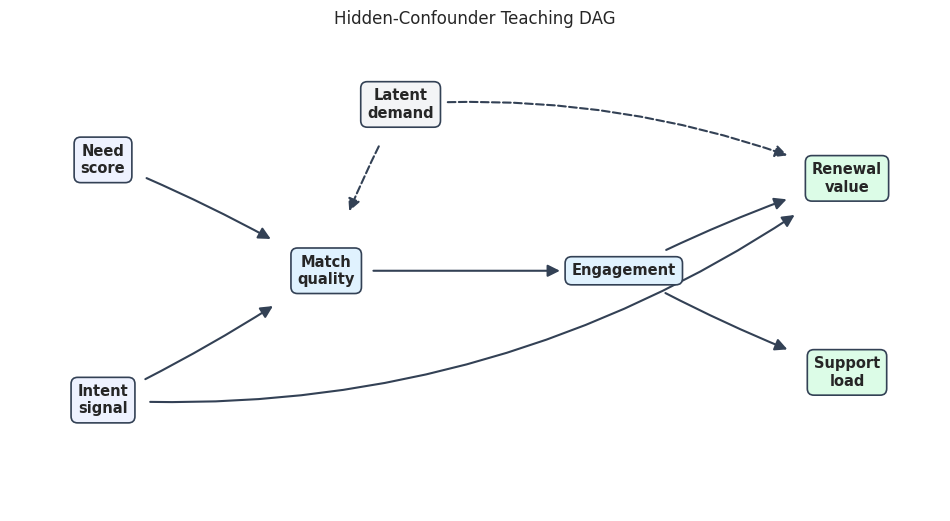

,source,target,edge_type,mechanism
0,need,match,directed,Need changes what a good match means.
1,intent,match,directed,Current intent changes recommendation relevance.
2,match,engagement,directed,Better matching increases engagement depth.
3,intent,renewal,directed,Intent directly affects later value.
4,engagement,renewal,directed,Engagement contributes to renewal value.
5,engagement,support,directed,Engagement creates more chances for support contact.
6,latent_demand,match,latent,Unobserved demand makes better matches more likely.
7,latent_demand,renewal,latent,The same unobserved demand also affects renewal.


In [12]:
hidden_labels = {
    **base_labels,
    "latent_demand": "Latent\ndemand",
}
hidden_positions = {
    **base_positions,
    "latent_demand": (0.42, 0.88),
}
hidden_node_colors = {
    **base_node_colors,
    "latent_demand": "#f3f4f6",
}
hidden_edge_table = pd.concat(
    [
        base_edge_table,
        pd.DataFrame(
            [
                {
                    "source": "latent_demand",
                    "target": "match",
                    "edge_type": "latent",
                    "mechanism": "Unobserved demand makes better matches more likely.",
                },
                {
                    "source": "latent_demand",
                    "target": "renewal",
                    "edge_type": "latent",
                    "mechanism": "The same unobserved demand also affects renewal.",
                },
            ]
        ),
    ],
    ignore_index=True,
)
hidden_edge_radii = {
    **base_edge_radii,
    ("latent_demand", "match"): 0.04,
    ("latent_demand", "renewal"): -0.12,
}

hidden_dag_path = FIGURE_DIR / f"{NOTEBOOK_PREFIX}_hidden_confounder_true_dag.png"
draw_teaching_style_dag(
    hidden_edge_table,
    hidden_labels,
    hidden_positions,
    hidden_node_colors,
    "Hidden-Confounder Teaching DAG",
    hidden_dag_path,
    edge_radii=hidden_edge_radii,
)

hidden_edge_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_hidden_confounder_full_true_edges.csv", index=False)
hidden_edge_table

The dashed latent edges show why this scenario is different from the base DAG. A learner that only sees observed variables cannot condition on `latent_demand`, so some observed relationships may look like direct or ambiguous causal connections.

## Generate The Hidden-Confounder Values

This cell generates the hidden-confounder data. The full table includes the latent variable so we can verify the data-generating process. The observed table removes it, because that is the realistic discovery input for a hidden-confounding tutorial.

In [13]:
def simulate_hidden_confounder(n_rows, seed):
    """Generate data where one common cause is hidden from the observed dataset."""
    local_rng = np.random.default_rng(seed)
    need = draw_noise(local_rng, n_rows, "normal", scale=1.0)
    intent = draw_noise(local_rng, n_rows, "normal", scale=1.0)
    latent_demand = draw_noise(local_rng, n_rows, "normal", scale=1.0)
    match = standardize(
        0.75 * need
        + 0.85 * intent
        + 0.80 * latent_demand
        + draw_noise(local_rng, n_rows, "normal", scale=0.65)
    )
    engagement = standardize(1.00 * match + draw_noise(local_rng, n_rows, "normal", scale=0.75))
    renewal = standardize(
        0.65 * intent
        + 0.55 * engagement
        + 0.70 * latent_demand
        + draw_noise(local_rng, n_rows, "normal", scale=0.80)
    )
    support = standardize(0.60 * engagement + draw_noise(local_rng, n_rows, "normal", scale=0.90))

    full = pd.DataFrame(
        {
            "need": need,
            "intent": intent,
            "latent_demand": latent_demand,
            "match": match,
            "engagement": engagement,
            "renewal": renewal,
            "support": support,
        }
    )
    observed = full.drop(columns="latent_demand")
    return observed, full

hidden_confounder_observed, hidden_confounder_full = simulate_hidden_confounder(N_ROWS, RANDOM_SEED + 5)
hidden_confounder_full.head()

,need,intent,latent_demand,match,engagement,renewal,support
0,-0.670177,0.916751,-1.978234,-0.811025,-0.543636,-1.056283,-0.760347
1,0.099398,0.355660,1.211701,0.738471,0.195636,1.231812,-0.037870
2,-1.912569,1.550731,1.095861,0.853338,0.529918,0.922433,0.886718
3,-1.953293,-0.835806,0.227012,-0.691733,-1.561579,-0.399516,-0.891322
4,-1.419799,1.690953,-1.899709,-0.839137,-0.319077,0.325408,-0.029369


The full diagnostic file makes the omitted cause visible to us as notebook authors. Later, when we hide `latent_demand`, we can explain exactly why a fully observed DAG assumption is no longer valid.

## Nonstationary Dataset

The nonstationary dataset adds an `environment` label. Each environment changes some root distributions and one mechanism strength. This gives later CD-NOD and stability notebooks a controlled example where pooling all rows hides important regime differences.

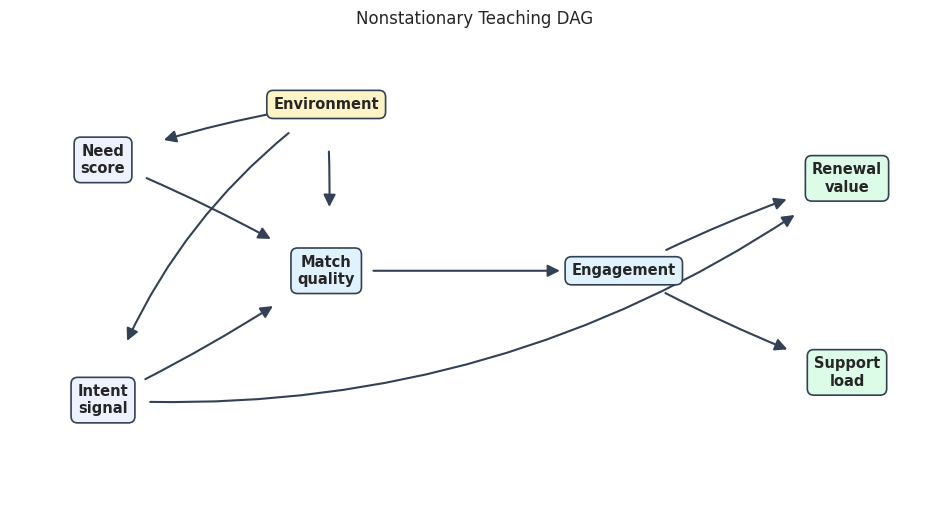

,source,target,edge_type,mechanism
4,engagement,renewal,directed,Engagement contributes to renewal value.
5,engagement,support,directed,Engagement creates more chances for support contact.
6,environment,need,directed,The root need distribution shifts by environment.
7,environment,intent,directed,The root intent distribution shifts by environment.
8,environment,match,directed,The intent-to-match mechanism changes by environment.


In [14]:
nonstationary_labels = {
    **base_labels,
    "environment": "Environment",
}
nonstationary_positions = {
    **base_positions,
    "environment": (0.34, 0.88),
}
nonstationary_node_colors = {
    **base_node_colors,
    "environment": "#fef3c7",
}
nonstationary_edge_table = pd.concat(
    [
        base_edge_table,
        pd.DataFrame(
            [
                {
                    "source": "environment",
                    "target": "need",
                    "edge_type": "directed",
                    "mechanism": "The root need distribution shifts by environment.",
                },
                {
                    "source": "environment",
                    "target": "intent",
                    "edge_type": "directed",
                    "mechanism": "The root intent distribution shifts by environment.",
                },
                {
                    "source": "environment",
                    "target": "match",
                    "edge_type": "directed",
                    "mechanism": "The intent-to-match mechanism changes by environment.",
                },
            ]
        ),
    ],
    ignore_index=True,
)
nonstationary_edge_radii = {
    **base_edge_radii,
    ("environment", "need"): 0.05,
    ("environment", "intent"): 0.16,
    ("environment", "match"): -0.04,
}

nonstationary_dag_path = FIGURE_DIR / f"{NOTEBOOK_PREFIX}_nonstationary_true_dag.png"
draw_teaching_style_dag(
    nonstationary_edge_table,
    nonstationary_labels,
    nonstationary_positions,
    nonstationary_node_colors,
    "Nonstationary Teaching DAG",
    nonstationary_dag_path,
    edge_radii=nonstationary_edge_radii,
)

nonstationary_edge_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_nonstationary_true_edges.csv", index=False)
nonstationary_edge_table.tail(5)

The environment node is drawn as an observed context. It is not an outcome we are trying to explain; it marks regimes where data distributions and mechanisms can change.

## Generate The Nonstationary Values

This cell creates three environments with different root means and different `intent -> match` strengths. The graph among product variables remains recognizable, but the data distribution is no longer exchangeable across all rows.

In [15]:
def simulate_nonstationary(n_rows, seed):
    """Generate continuous data across multiple environments with shifting mechanisms."""
    local_rng = np.random.default_rng(seed)
    environment = np.tile(np.array([0, 1, 2]), int(np.ceil(n_rows / 3)))[:n_rows]
    local_rng.shuffle(environment)

    need_mean = np.choose(environment, [-0.45, 0.00, 0.45])
    intent_mean = np.choose(environment, [0.35, 0.00, -0.35])
    intent_to_match = np.choose(environment, [0.65, 0.90, 1.15])

    need = standardize(need_mean + draw_noise(local_rng, n_rows, "normal", scale=0.95))
    intent = standardize(intent_mean + draw_noise(local_rng, n_rows, "normal", scale=0.95))
    match = standardize(
        0.80 * need
        + intent_to_match * intent
        + draw_noise(local_rng, n_rows, "normal", scale=0.70)
    )
    engagement = standardize(1.05 * match + draw_noise(local_rng, n_rows, "normal", scale=0.75))
    renewal = standardize(0.70 * intent + 0.55 * engagement + draw_noise(local_rng, n_rows, "normal", scale=0.80))
    support = standardize(0.65 * engagement + draw_noise(local_rng, n_rows, "normal", scale=0.90))

    return pd.DataFrame(
        {
            "environment": environment,
            "need": need,
            "intent": intent,
            "match": match,
            "engagement": engagement,
            "renewal": renewal,
            "support": support,
        }
    )

nonstationary_continuous = simulate_nonstationary(N_ROWS, RANDOM_SEED + 6)
nonstationary_continuous.head()

,environment,need,intent,match,engagement,renewal,support
0,2,0.500619,0.652311,0.607523,1.021798,1.464456,-0.695260
1,2,-0.068357,-0.635389,-0.603599,0.376130,-0.156033,-0.285916
2,1,-0.257764,-3.403817,-2.065930,-2.199955,-2.253464,-1.407673
3,0,-0.050100,0.439419,0.707436,0.980496,1.322518,0.062189
4,2,0.562090,-1.236711,0.163411,0.369901,-0.825164,-0.460469


The first rows look ordinary, but the `environment` column tells us they come from different regimes. Later notebooks can compare pooled discovery against environment-aware diagnostics.

## Save All Datasets

Now we save each dataset and its matching true edge table. The observed hidden-confounder dataset uses the base observed edges as the visible structural reference, while the full hidden edge table is saved separately for diagnostics.

In [16]:
scenario_notes = {
    "linear_gaussian": [
        {"note_type": "assumption", "note": "Linear additive structural equations with Gaussian noise."},
        {"note_type": "intended_use", "note": "Friendly baseline for Fisher-Z PC and score-based search."},
    ],
    "linear_nongaussian": [
        {"note_type": "assumption", "note": "Linear additive structural equations with Laplace and Student-t noise."},
        {"note_type": "intended_use", "note": "Useful for LiNGAM-style non-Gaussian direction examples."},
    ],
    "nonlinear_continuous": [
        {"note_type": "assumption", "note": "Nonlinear mechanisms with interactions, but the same parent sets as the base DAG."},
        {"note_type": "intended_use", "note": "Useful for kernel tests and nonlinear method cautions."},
    ],
    "discrete_mixed": [
        {"note_type": "assumption", "note": "Binary and ordinal values generated from latent logits."},
        {"note_type": "intended_use", "note": "Useful for discrete-data tests and mixed-data caveats."},
    ],
    "hidden_confounder_observed": [
        {"note_type": "assumption", "note": "Observed file omits latent_demand, which affects match and renewal."},
        {"note_type": "intended_use", "note": "Useful for FCI/PAG hidden-confounding examples."},
    ],
    "hidden_confounder_full": [
        {"note_type": "assumption", "note": "Diagnostic file includes latent_demand so the hidden-confounding design can be verified."},
        {"note_type": "intended_use", "note": "Do not use as the observed discovery input unless teaching oracle access."},
    ],
    "nonstationary_continuous": [
        {"note_type": "assumption", "note": "Environment changes root distributions and one mechanism strength."},
        {"note_type": "intended_use", "note": "Useful for CD-NOD and environment-stability examples."},
    ],
}

saved_files = []
saved_files.append(save_dataset("linear_gaussian", linear_gaussian, base_edge_table, scenario_notes["linear_gaussian"]))
saved_files.append(save_dataset("linear_nongaussian", linear_nongaussian, base_edge_table, scenario_notes["linear_nongaussian"]))
saved_files.append(save_dataset("nonlinear_continuous", nonlinear_continuous, base_edge_table, scenario_notes["nonlinear_continuous"]))
saved_files.append(save_dataset("discrete_mixed", discrete_mixed, base_edge_table, scenario_notes["discrete_mixed"]))
saved_files.append(save_dataset("hidden_confounder_observed", hidden_confounder_observed, base_edge_table, scenario_notes["hidden_confounder_observed"]))
saved_files.append(save_dataset("hidden_confounder_full", hidden_confounder_full, hidden_edge_table, scenario_notes["hidden_confounder_full"]))
saved_files.append(save_dataset("nonstationary_continuous", nonstationary_continuous, nonstationary_edge_table, scenario_notes["nonstationary_continuous"]))

saved_file_table = pd.DataFrame(saved_files)
saved_file_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_saved_dataset_files.csv", index=False)
saved_file_table

,dataset_name,data_path,edge_path,notes_path,rows,columns
0,linear_gaussian,outputs/datasets/02_linear_gaussian.csv,outputs/tables/02_linear_gaussian_true_edges.csv,outputs/tables/02_linear_gaussian_notes.csv,2500,6
1,linear_nongaussian,outputs/datasets/02_linear_nongaussian.csv,outputs/tables/02_linear_nongaussian_true_edges.csv,outputs/tables/02_linear_nongaussian_notes.csv,2500,6
2,nonlinear_continuous,outputs/datasets/02_nonlinear_continuous.csv,outputs/tables/02_nonlinear_continuous_true_edges.csv,outputs/tables/02_nonlinear_continuous_notes.csv,2500,6
3,discrete_mixed,outputs/datasets/02_discrete_mixed.csv,outputs/tables/02_discrete_mixed_true_edges.csv,outputs/tables/02_discrete_mixed_notes.csv,2500,6
4,hidden_confounder_observed,outputs/datasets/02_hidden_confounder_observed.csv,outputs/tables/02_hidden_confounder_observed_true_edges.csv,outputs/tables/02_hidden_confounder_observed_notes.csv,2500,6
5,hidden_confounder_full,outputs/datasets/02_hidden_confounder_full.csv,outputs/tables/02_hidden_confounder_full_true_edges.csv,outputs/tables/02_hidden_confounder_full_notes.csv,2500,7
6,nonstationary_continuous,outputs/datasets/02_nonstationary_continuous.csv,outputs/tables/02_nonstationary_continuous_true_edges.csv,outputs/tables/02_nonstationary_continuous_notes.csv,2500,7


The saved file table is what downstream notebooks should use. The distinction between `hidden_confounder_observed` and `hidden_confounder_full` is important: discovery should use the observed file, while teaching diagnostics can use the full file.

## Shape And Missingness Checks

Generated data should still be audited. The next cell checks shape, column order, and missingness for every saved dataset. A synthetic generator that silently creates missing values or inconsistent columns would make later algorithm behavior harder to explain.

In [17]:
datasets = {
    "linear_gaussian": linear_gaussian,
    "linear_nongaussian": linear_nongaussian,
    "nonlinear_continuous": nonlinear_continuous,
    "discrete_mixed": discrete_mixed,
    "hidden_confounder_observed": hidden_confounder_observed,
    "hidden_confounder_full": hidden_confounder_full,
    "nonstationary_continuous": nonstationary_continuous,
}

shape_rows = []
for name, data in datasets.items():
    shape_rows.append(
        {
            "dataset_name": name,
            "rows": data.shape[0],
            "columns": data.shape[1],
            "column_list": ", ".join(data.columns),
            "total_missing_values": int(data.isna().sum().sum()),
        }
    )

shape_check = pd.DataFrame(shape_rows)
shape_check.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_shape_and_missingness_checks.csv", index=False)
shape_check

,dataset_name,rows,columns,column_list,total_missing_values
0,linear_gaussian,2500,6,"need, intent, match, engagement, renewal, support",0
1,linear_nongaussian,2500,6,"need, intent, match, engagement, renewal, support",0
2,nonlinear_continuous,2500,6,"need, intent, match, engagement, renewal, support",0
3,discrete_mixed,2500,6,"need, intent, match, engagement, renewal, support",0
4,hidden_confounder_observed,2500,6,"need, intent, match, engagement, renewal, support",0
5,hidden_confounder_full,2500,7,"need, intent, latent_demand, match, engagement, renewal, support",0
6,nonstationary_continuous,2500,7,"environment, need, intent, match, engagement, renewal, support",0


All generated datasets should have the intended number of rows and no missing values. This keeps later discovery behavior focused on causal assumptions rather than data-cleaning artifacts.

## Continuous Summary Statistics

This summary checks whether the continuous datasets are roughly centered and scaled. Standardization does not make all scenarios identical: non-Gaussian and nonlinear datasets can still differ in skew, kurtosis, and dependence patterns.

In [18]:
continuous_dataset_names = [
    "linear_gaussian",
    "linear_nongaussian",
    "nonlinear_continuous",
    "hidden_confounder_observed",
    "nonstationary_continuous",
]

summary_rows = []
for name in continuous_dataset_names:
    data = datasets[name].drop(columns=["environment"], errors="ignore")
    for column in base_nodes:
        series = data[column]
        summary_rows.append(
            {
                "dataset_name": name,
                "variable": column,
                "mean": series.mean(),
                "std": series.std(ddof=0),
                "min": series.min(),
                "median": series.median(),
                "max": series.max(),
                "skew": series.skew(),
                "kurtosis": series.kurtosis(),
            }
        )

continuous_summary = pd.DataFrame(summary_rows)
continuous_summary.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_continuous_summary_statistics.csv", index=False)
continuous_summary.head(12)

,dataset_name,variable,mean,std,min,median,max,skew,kurtosis
0,linear_gaussian,need,7.105427e-18,1.0,-3.371900,0.019662,3.316358,-0.010639,0.003971
1,linear_gaussian,intent,-1.136868e-17,1.0,-3.467962,-0.012950,3.389982,0.020848,-0.077626
2,linear_gaussian,match,-2.131628e-18,1.0,-3.596272,0.001127,3.917631,-0.027569,0.014416
3,linear_gaussian,engagement,-6.394885e-18,1.0,-3.404627,0.004449,3.469112,-0.032966,0.018805
4,linear_gaussian,renewal,-7.105427e-18,1.0,-3.418065,-0.024579,3.122549,0.111052,-0.119672
5,linear_gaussian,support,6.394885e-18,1.0,-3.250120,-0.007028,3.174916,-0.022463,-0.203720
6,linear_nongaussian,need,1.421085e-17,1.0,-6.499779,0.007874,6.786758,-0.064023,3.522823
7,linear_nongaussian,intent,1.136868e-17,1.0,-7.262542,0.016406,6.225672,-0.244536,5.495513
8,linear_nongaussian,match,1.421085e-17,1.0,-5.379496,0.008311,4.600044,-0.154743,1.669282
9,linear_nongaussian,engagement,5.684342e-18,1.0,-4.766194,0.006455,5.646124,0.020379,1.669102


The means are close to zero and standard deviations are close to one because of standardization. The skew and kurtosis columns are more revealing: they help distinguish Gaussian-style data from heavier-tailed or nonlinear scenarios.

## Distribution Shape Comparison

The next plot compares the marginal distribution of `renewal` across the continuous scenarios. This is a quick visual reminder that datasets can share a graph while having different noise and functional assumptions.

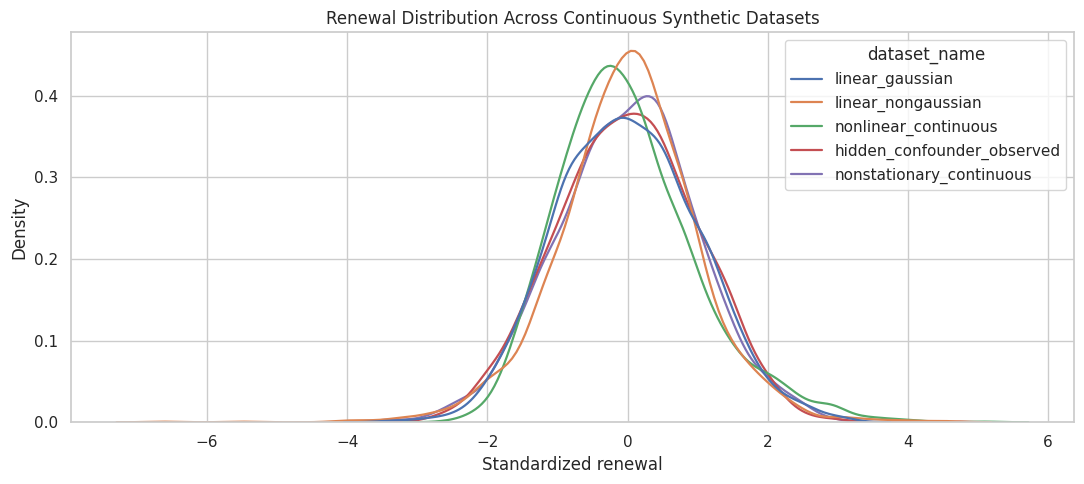

In [19]:
density_plot_df = pd.concat(
    [
        datasets[name].assign(dataset_name=name)[["dataset_name", "renewal"]]
        for name in continuous_dataset_names
    ],
    ignore_index=True,
)

fig, ax = plt.subplots(figsize=(11, 5))
sns.kdeplot(
    data=density_plot_df,
    x="renewal",
    hue="dataset_name",
    common_norm=False,
    linewidth=1.6,
    ax=ax,
)
ax.set_title("Renewal Distribution Across Continuous Synthetic Datasets")
ax.set_xlabel("Standardized renewal")
ax.set_ylabel("Density")
plt.tight_layout()
renewal_density_path = FIGURE_DIR / f"{NOTEBOOK_PREFIX}_renewal_distribution_comparison.png"
fig.savefig(renewal_density_path, dpi=160, bbox_inches="tight")
plt.show()

The density curves show that the same variable can have different distributional behavior across scenarios. This matters because some discovery methods are designed for Gaussian data, while others rely on non-Gaussianity or nonlinear dependence.

## Parent-Child Signal Checks

A good teaching dataset should contain detectable signal along true edges. This cell computes correlations for every true parent-child pair in the base DAG and compares them with a few non-edge pairs. Correlation is not a causal proof, but it is a useful generator sanity check.

In [20]:
non_edge_pairs = [
    ("need", "support"),
    ("intent", "support"),
    ("need", "engagement"),
    ("match", "renewal"),
]

signal_rows = []
for name in ["linear_gaussian", "linear_nongaussian", "nonlinear_continuous", "hidden_confounder_observed"]:
    data = datasets[name]
    for row in base_edge_table.itertuples(index=False):
        signal_rows.append(
            {
                "dataset_name": name,
                "pair_type": "true_edge",
                "source": row.source,
                "target": row.target,
                "correlation": data[row.source].corr(data[row.target]),
            }
        )
    for source, target in non_edge_pairs:
        signal_rows.append(
            {
                "dataset_name": name,
                "pair_type": "selected_non_edge",
                "source": source,
                "target": target,
                "correlation": data[source].corr(data[target]),
            }
        )

edge_signal_checks = pd.DataFrame(signal_rows)
edge_signal_checks.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_edge_signal_checks.csv", index=False)
edge_signal_checks.head(16)

,dataset_name,pair_type,source,target,correlation
0,linear_gaussian,true_edge,need,match,0.595021
1,linear_gaussian,true_edge,intent,match,0.638324
2,linear_gaussian,true_edge,match,engagement,0.820921
3,linear_gaussian,true_edge,intent,renewal,0.735233
4,linear_gaussian,true_edge,engagement,renewal,0.670390
5,linear_gaussian,true_edge,engagement,support,0.582085
6,linear_gaussian,selected_non_edge,need,support,0.311135
7,linear_gaussian,selected_non_edge,intent,support,0.307245
8,linear_gaussian,selected_non_edge,need,engagement,0.493543
9,linear_gaussian,selected_non_edge,match,renewal,0.665300


True edges generally show clear association, but some selected non-edges can also be associated through indirect paths. This is exactly why causal discovery needs conditional-independence logic rather than simple pairwise correlation alone.

## Correlation Heatmaps

The heatmaps give a compact view of pairwise dependence across scenarios. They are not graph estimates. They are diagnostic maps that help us see whether the generated data contain the broad dependence patterns implied by the structural equations.

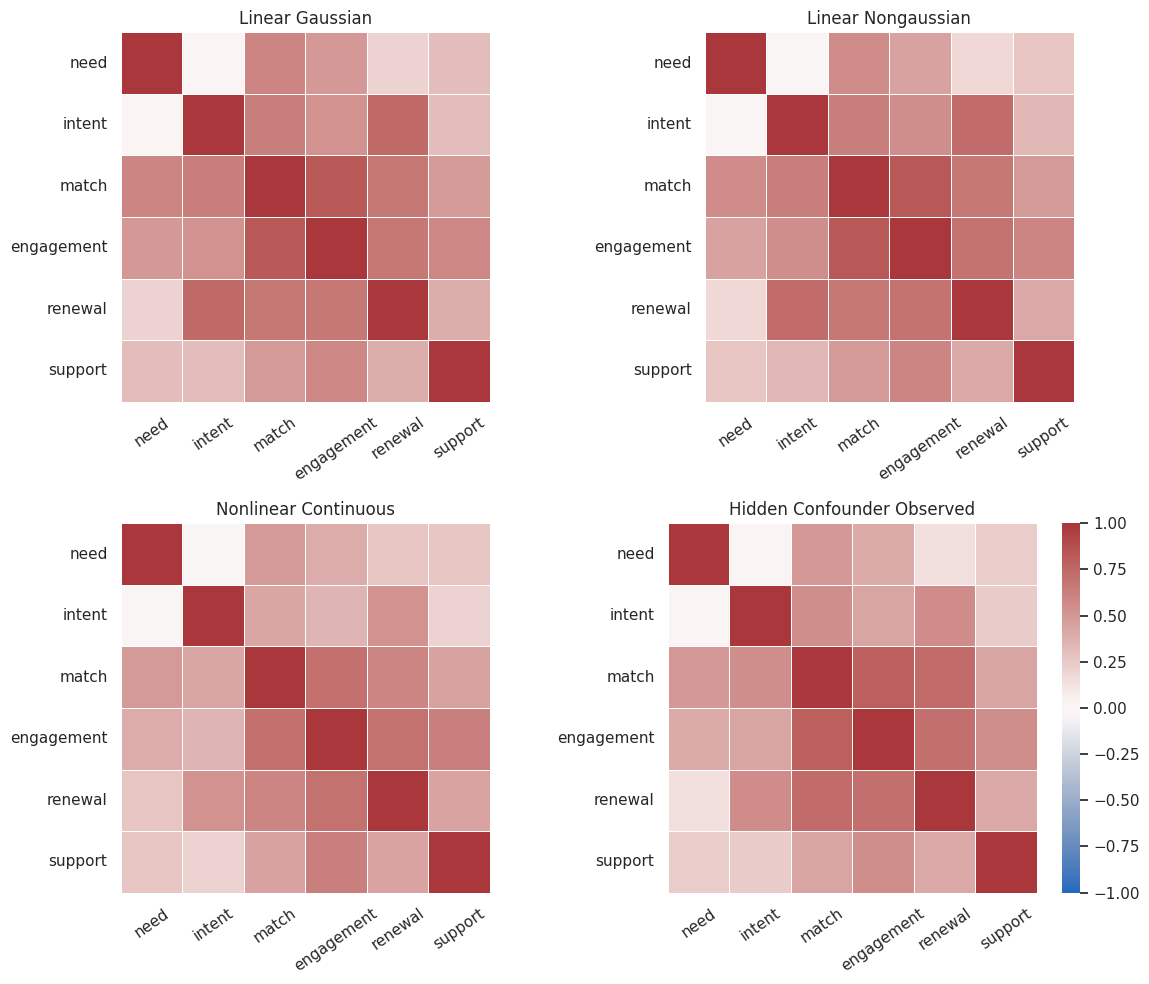

In [21]:
heatmap_names = ["linear_gaussian", "linear_nongaussian", "nonlinear_continuous", "hidden_confounder_observed"]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for ax, name in zip(axes, heatmap_names):
    corr = datasets[name][base_nodes].corr()
    sns.heatmap(
        corr,
        vmin=-1,
        vmax=1,
        center=0,
        cmap="vlag",
        square=True,
        linewidths=0.5,
        cbar=name == heatmap_names[-1],
        ax=ax,
    )
    ax.set_title(name.replace("_", " ").title())
    ax.tick_params(axis="x", rotation=35)
    ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
correlation_heatmap_path = FIGURE_DIR / f"{NOTEBOOK_PREFIX}_scenario_correlation_heatmaps.png"
fig.savefig(correlation_heatmap_path, dpi=160, bbox_inches="tight")
plt.show()

The heatmaps show strong dependence blocks around `match`, `engagement`, and downstream outcomes. The hidden-confounder version can look similar to the base data in pairwise correlations, which is why hidden confounding is hard to rule out from simple summaries.

## Discrete Dataset Checks

For the discrete dataset, means are easier to read as rates or average ordinal levels. This cell reports value counts and rates so later notebooks know what class balance they are working with.

In [22]:
discrete_rate_rows = []
for column in discrete_mixed.columns:
    value_counts = discrete_mixed[column].value_counts(normalize=True).sort_index()
    for value, share in value_counts.items():
        discrete_rate_rows.append(
            {
                "variable": column,
                "value": int(value),
                "share": share,
                "count": int((discrete_mixed[column] == value).sum()),
            }
        )

discrete_value_rates = pd.DataFrame(discrete_rate_rows)
discrete_value_rates.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_discrete_value_rates.csv", index=False)
discrete_value_rates

,variable,value,share,count
0,need,0,0.5076,1269
1,need,1,0.4924,1231
2,intent,0,0.4960,1240
3,intent,1,0.5040,1260
4,match,0,0.4160,1040
5,match,1,0.5840,1460
6,engagement,0,0.2992,748
7,engagement,1,0.4124,1031
8,engagement,2,0.2884,721
9,renewal,0,0.4692,1173


The classes are not perfectly balanced, which is intentional. Discovery examples with discrete data should include realistic imbalance, but not so much imbalance that the teaching signal disappears.

## Hidden-Confounder Diagnostics

Because we generated the hidden variable ourselves, we can check how strongly it relates to the observed variables it affects. A real dataset would not give us this luxury; that is exactly why this synthetic scenario is useful for teaching.

In [23]:
hidden_diagnostics = pd.DataFrame(
    [
        {
            "relationship": "latent_demand with match",
            "correlation": hidden_confounder_full["latent_demand"].corr(hidden_confounder_full["match"]),
            "why_it_matters": "Latent demand partly drives observed match quality.",
        },
        {
            "relationship": "latent_demand with renewal",
            "correlation": hidden_confounder_full["latent_demand"].corr(hidden_confounder_full["renewal"]),
            "why_it_matters": "Latent demand also drives renewal, creating unobserved common-cause risk.",
        },
        {
            "relationship": "match with renewal in observed file",
            "correlation": hidden_confounder_observed["match"].corr(hidden_confounder_observed["renewal"]),
            "why_it_matters": "Observed association may mix directed, indirect, and hidden-confounding paths.",
        },
    ]
)

hidden_diagnostics.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_hidden_confounder_diagnostics.csv", index=False)
hidden_diagnostics

,relationship,correlation,why_it_matters
0,latent_demand with match,0.508012,Latent demand partly drives observed match quality.
1,latent_demand with renewal,0.580324,"Latent demand also drives renewal, creating unobserved common-cause risk."
2,match with renewal in observed file,0.733291,"Observed association may mix directed, indirect, and hidden-confounding paths."


The latent variable is correlated with both `match` and `renewal`, as designed. Later, FCI-style methods can use the observed file to demonstrate why a PAG may be more honest than forcing a fully observed DAG.

## Nonstationarity Diagnostics

The nonstationary dataset should show environment-level differences. This cell summarizes means and standard deviations by environment, then plots the main mechanism shift we designed into the data.

In [24]:
nonstationary_summary = (
    nonstationary_continuous
    .groupby("environment")
    .agg(
        rows=("environment", "size"),
        need_mean=("need", "mean"),
        intent_mean=("intent", "mean"),
        match_mean=("match", "mean"),
        renewal_mean=("renewal", "mean"),
        support_mean=("support", "mean"),
    )
    .reset_index()
)

nonstationary_summary.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_nonstationary_environment_summary.csv", index=False)
nonstationary_summary

,environment,rows,need_mean,intent_mean,match_mean,renewal_mean,support_mean
0,0,834,-0.419768,0.334375,-0.048747,0.109419,-0.025874
1,1,833,-0.047202,0.027199,0.044692,0.060080,0.037340
2,2,833,0.467474,-0.361976,0.004113,-0.169630,-0.011435


The environment means differ because we intentionally changed root distributions and mechanism strength. That makes this dataset useful for tutorials about stationarity assumptions and environment-aware discovery.

## Visualize The Environment Shift

This scatterplot shows `intent` against `match` by environment. The relationship is not identical across regimes, which is the mechanism shift built into the generator.

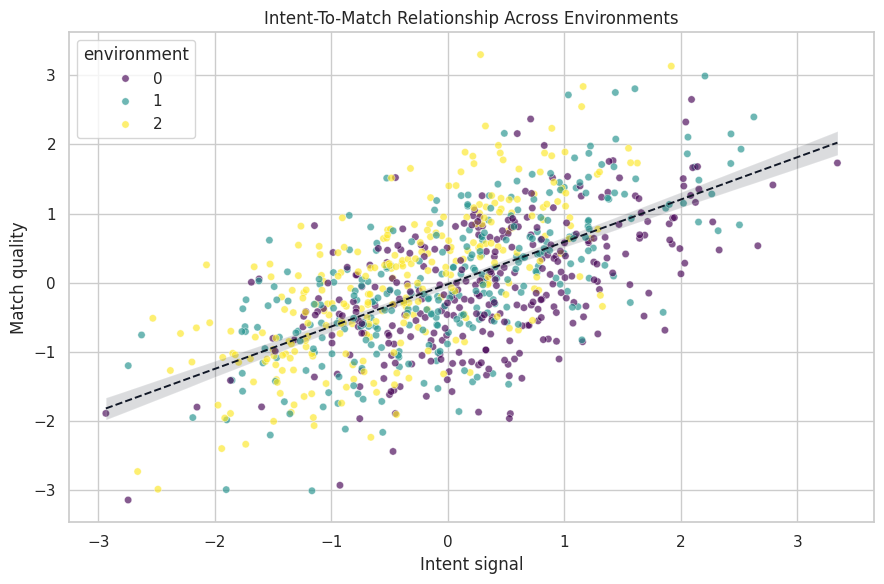

In [25]:
plot_sample = nonstationary_continuous.sample(n=900, random_state=RANDOM_SEED)
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(
    data=plot_sample,
    x="intent",
    y="match",
    hue="environment",
    palette="viridis",
    alpha=0.65,
    s=28,
    ax=ax,
)
sns.regplot(
    data=plot_sample,
    x="intent",
    y="match",
    scatter=False,
    color="#111827",
    line_kws={"linewidth": 1.4, "linestyle": "--"},
    ax=ax,
)
ax.set_title("Intent-To-Match Relationship Across Environments")
ax.set_xlabel("Intent signal")
ax.set_ylabel("Match quality")
plt.tight_layout()
nonstationary_shift_path = FIGURE_DIR / f"{NOTEBOOK_PREFIX}_nonstationary_intent_match_shift.png"
fig.savefig(nonstationary_shift_path, dpi=160, bbox_inches="tight")
plt.show()

The pooled dashed line summarizes all environments at once, while the colored points show that the data are not generated from one perfectly stable regime. Later notebooks can use this to motivate environment-specific checks before trusting one pooled graph.

## Scenario Comparison Table

The next table combines shape, type, and intended use into a compact catalog. It is the quickest reference for choosing the right synthetic dataset in later notebooks.

In [26]:
scenario_catalog = (
    dataset_registry
    .merge(shape_check[["dataset_name", "rows", "columns", "total_missing_values"]], on="dataset_name", how="left")
    .merge(saved_file_table[["dataset_name", "data_path", "edge_path"]], on="dataset_name", how="left")
)

# Add the full hidden diagnostic file, which is intentionally not in the main registry.
hidden_full_row = saved_file_table[saved_file_table["dataset_name"].eq("hidden_confounder_full")].assign(
    row_count=N_ROWS,
    variable_type="continuous with latent column",
    main_stress_test="Diagnostic oracle file for the hidden-confounder scenario.",
    use_later_for="Diagnostics only; observed discovery should omit latent_demand.",
    known_limitation="Not a realistic observed discovery input.",
    total_missing_values=0,
)
scenario_catalog = pd.concat(
    [
        scenario_catalog,
        hidden_full_row[
            [
                "dataset_name",
                "row_count",
                "variable_type",
                "main_stress_test",
                "use_later_for",
                "known_limitation",
                "rows",
                "columns",
                "total_missing_values",
                "data_path",
                "edge_path",
            ]
        ],
    ],
    ignore_index=True,
)

scenario_catalog.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_scenario_catalog.csv", index=False)
scenario_catalog

,dataset_name,row_count,variable_type,main_stress_test,use_later_for,known_limitation,rows,columns,total_missing_values,data_path,edge_path
0,linear_gaussian,2500,continuous,Linear additive mechanisms with Gaussian noise.,"PC, Fisher-Z tests, GES, baseline graph recovery.",Purely observational data may not orient every Markov-equivalent edge.,2500,6,0,outputs/datasets/02_linear_gaussian.csv,outputs/tables/02_linear_gaussian_true_edges.csv
1,linear_nongaussian,2500,continuous,Linear mechanisms with non-Gaussian noise.,LiNGAM-style direction learning and non-Gaussian diagnostics.,Non-Gaussianity helps only when the linear model is a reasonable approximation.,2500,6,0,outputs/datasets/02_linear_nongaussian.csv,outputs/tables/02_linear_nongaussian_true_edges.csv
2,nonlinear_continuous,2500,continuous,Nonlinear parent effects and interactions.,"Kernel tests, nonlinear functional methods, robustness checks.",Linear tests may miss or distort nonlinear dependence.,2500,6,0,outputs/datasets/02_nonlinear_continuous.csv,outputs/tables/02_nonlinear_continuous_true_edges.csv
3,discrete_mixed,2500,binary and ordinal,Discrete outcomes generated from latent logits.,Discrete conditional-independence tests and mixed-data cautions.,Treating these variables as Gaussian continuous data is a modeling mismatch.,2500,6,0,outputs/datasets/02_discrete_mixed.csv,outputs/tables/02_discrete_mixed_true_edges.csv
4,hidden_confounder_observed,2500,continuous with one omitted cause,A latent variable affects multiple observed variables.,FCI/PAG examples and hidden-confounding sensitivity.,The observed variables alone do not satisfy causal sufficiency.,2500,6,0,outputs/datasets/02_hidden_confounder_observed.csv,outputs/tables/02_hidden_confounder_observed_true_edges.csv
5,nonstationary_continuous,2500,continuous plus environment label,Mechanisms and distributions shift across environments.,CD-NOD and stability diagnostics across environments.,Pooling environments can hide mechanism changes.,2500,7,0,outputs/datasets/02_nonstationary_continuous.csv,outputs/tables/02_nonstationary_continuous_true_edges.csv
6,hidden_confounder_full,2500,continuous with latent column,Diagnostic oracle file for the hidden-confounder scenario.,Diagnostics only; observed discovery should omit latent_demand.,Not a realistic observed discovery input.,2500,7,0,outputs/datasets/02_hidden_confounder_full.csv,outputs/tables/02_hidden_confounder_full_true_edges.csv


The catalog makes downstream notebook choices explicit. For example, the PC notebook should start with `linear_gaussian`, while the FCI notebook should use `hidden_confounder_observed` and explain why the full hidden file is only for diagnostics.

## Generated Artifact Manifest

The final cell lists all files generated by this notebook. This is a practical audit trail: if a later notebook cannot find a file, this manifest tells us whether it was created here and where it should live.

In [27]:
artifact_paths = sorted(
    list(DATASET_DIR.glob(f"{NOTEBOOK_PREFIX}_*"))
    + list(TABLE_DIR.glob(f"{NOTEBOOK_PREFIX}_*"))
    + list(FIGURE_DIR.glob(f"{NOTEBOOK_PREFIX}_*"))
)

artifact_manifest = pd.DataFrame(
    [
        {
            "artifact_type": (
                "dataset" if path.parent == DATASET_DIR else "figure" if path.parent == FIGURE_DIR else "table"
            ),
            "path": str(path.relative_to(NOTEBOOK_DIR)),
            "size_kb": round(path.stat().st_size / 1024, 1),
        }
        for path in artifact_paths
    ]
)

artifact_manifest.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_artifact_manifest.csv", index=False)
artifact_manifest

,artifact_type,path,size_kb
0,dataset,outputs/datasets/02_discrete_mixed.csv,29.3
1,dataset,outputs/datasets/02_hidden_confounder_full.csv,335.4
2,dataset,outputs/datasets/02_hidden_confounder_observed.csv,287.5
3,dataset,outputs/datasets/02_linear_gaussian.csv,287.6
4,dataset,outputs/datasets/02_linear_nongaussian.csv,288.5
5,dataset,outputs/datasets/02_nonlinear_continuous.csv,288.3
6,dataset,outputs/datasets/02_nonstationary_continuous.csv,292.5
7,figure,outputs/figures/02_base_teaching_dag.png,64.6
8,figure,outputs/figures/02_hidden_confounder_true_dag.png,80.6
9,figure,outputs/figures/02_nonstationary_intent_match_shift.png,269.5


The synthetic data factory is now ready. The next tutorial can focus on conditional-independence tests because it can load known datasets from `outputs/datasets` and compare test behavior against documented ground truth.